## 1. Import Libraries & Configuration

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# GPU libraries
import cudf
import cupy as cp
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
from config.gpu_config import (
    PARQUET_SNAPSHOTS_DIR,
    PARQUET_TICKER_DIR,
    PARQUET_FEATURES_DIR,
    SNAPSHOT_INTERVAL_SEC
)

# Utilities
from datetime import datetime, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported")
print(f"Snapshot data: {PARQUET_SNAPSHOTS_DIR}")
print(f"Ticker data: {PARQUET_TICKER_DIR}")
print(f"Features output: {PARQUET_FEATURES_DIR}")

✓ Libraries imported
Snapshot data: /home/nvlabs/Desktop/abhijit/Market-Prediction/datasets/parquet/snapshots
Ticker data: /home/nvlabs/Desktop/abhijit/Market-Prediction/datasets/parquet/ticker
Features output: /home/nvlabs/Desktop/abhijit/Market-Prediction/datasets/parquet/features


## 2. Load Orderbook Snapshots

Load reconstructed orderbook snapshots from previous notebook.

In [2]:
import gc
import os

# 1. Force Memory Cleanup (Crucial after Step 02)
gc.collect()
try:
    import cupy as cp
    cp.get_default_memory_pool().free_all_blocks()
    print("🧹 GPU Memory cleaned")
except ImportError:
    pass

# 2. Find Files
snapshots_path = Path(PARQUET_SNAPSHOTS_DIR)
# Use sorted() to ensure consistent testing
snapshot_files = sorted(list(snapshots_path.glob("date=*/product_id=*/snapshots.parquet")))

print(f"Found {len(snapshot_files)} snapshot files")

if len(snapshot_files) == 0:
    print("No snapshot files found! Please check PARQUET_SNAPSHOTS_DIR path.")
    print(f"Path: {PARQUET_SNAPSHOTS_DIR}")
else:
    # Select first file
    test_file = snapshot_files[0]
    file_size_mb = test_file.stat().st_size / (1024 * 1024)
    
    print(f"\nTarget File: {test_file.name}")
    print(f"Size: {file_size_mb:.2f} MB")
    
    # 3. Safe Load Strategy
    try:
        print("Attempting CPU Load (Pandas)...")
        # Load with Pandas first (Crash-proof way to check data integrity)
        pdf = pd.read_parquet(test_file)
        print(f"CPU Load Successful: {len(pdf)} rows")
        
        print("Transferring to GPU (cuDF)...")
        # Move to GPU explicitly
        snapshots_df = cudf.from_pandas(pdf)
        print(f"GPU Load Successful")

        # Extract metadata
        parts = str(test_file).split('/')
        # Handle both Linux (/) and Windows (\) paths robustly
        try:
            date = [p for p in parts if 'date=' in p][0].split('=')[1]
            product_id = [p for p in parts if 'product_id=' in p][0].split('=')[1]
        except:
            date = "unknown"
            product_id = "unknown"

        print(f"\nDate: {date}")
        print(f"Product: {product_id}")
        print(f"Time Range: {snapshots_df['timestamp'].min()} to {snapshots_df['timestamp'].max()}")
        
        # Display
        print(snapshots_df.head(3))
        
        # Cleanup CPU copy
        del pdf
        gc.collect()

    except Exception as e:
        print(f"\n LOAD FAILED: {str(e)}")
        print("Suggestion: Restart the Kernel (Kernel -> Restart Kernel) to clear VRAM.")

🧹 GPU Memory cleaned
Found 32 snapshot files

Target File: snapshots.parquet
Size: 1.04 MB
Attempting CPU Load (Pandas)...
✅ CPU Load Successful: 8594 rows
Transferring to GPU (cuDF)...
✅ GPU Load Successful

Date: 2025-11-08
Product: BTC-USD
Time Range: 2025-11-07T18:30:10.396078000 to 2025-11-08T18:29:40.661019000
                   timestamp product_id   best_bid   best_ask  best_bid_qty  \
0 2025-11-07 18:30:10.396078    BTC-USD  102620.70  102620.71      0.081188   
1 2025-11-07 18:30:20.395013    BTC-USD  102599.30  102599.31      0.195204   
2 2025-11-07 18:30:30.386433    BTC-USD  102625.65  102629.92      0.095724   

   best_ask_qty  spread  spread_bps   mid_price   weighted_mid  ...  \
0      0.140185    0.01    0.000974  102620.705  102620.703667  ...   
1      0.020219    0.01    0.000975  102599.305  102599.309061  ...   
2      0.017014    4.27    0.416067  102627.785  102629.275570  ...   

   bid_volume_l10  ask_volume_l10  total_volume_l5  total_volume_l10  \
0       

## 3. Load Ticker Data (Trade Executions)

Ticker data provides actual trade prices and volumes for target variable creation.

In [3]:
import gc
import time
import pyarrow.parquet as pq
import cudf
import pandas as pd
from pathlib import Path
import numpy as np

print("LOADING TICKER DATA (SMART STREAMING)")
print("=" * 70)

# 1. Setup
gc.collect()
try:
    import cupy as cp
    cp.get_default_memory_pool().free_all_blocks()
except: pass

ticker_path = Path(PARQUET_TICKER_DIR)
ticker_file = ticker_path / f"date={date}" / f"product_id={product_id}" / "data.parquet"

if ticker_file.exists():
    print(f"Smart Streaming: {ticker_file.name}")
    
    try:
        # --- STEP 1: INSPECT SCHEMA ---
        parquet_file = pq.ParquetFile(ticker_file)
        file_cols = parquet_file.schema.names
        
        # Dynamic Column Mapping
        time_col = 'event_time'
        if 'event_time' not in file_cols:
            if 'timestamp' in file_cols: time_col = 'timestamp'
            elif 'time' in file_cols: time_col = 'time'
        
        # Check for available columns
        has_qty = 'quantity' in file_cols or 'size' in file_cols
        has_side = 'side' in file_cols
        
        # Define read columns
        read_cols = [time_col, 'price']
        if has_qty: 
            read_cols.append('quantity' if 'quantity' in file_cols else 'size')
        if has_side: 
            read_cols.append('side')

        # --- STEP 2: TIME BOUNDARIES ---
        # Convert to CPU/Naive timestamps for filtering
        min_ts = pd.Timestamp(snapshots_df['timestamp'].min()).tz_localize(None)
        max_ts = pd.Timestamp(snapshots_df['timestamp'].max()).tz_localize(None)
        
        buffer = pd.Timedelta(minutes=15)
        search_start = min_ts - buffer
        search_end = max_ts + buffer
        
        print(f"   Filtering: {search_start} to {search_end}")

        # --- STEP 3: STREAMING LOAD ---
        filtered_batches = []
        total_scanned = 0
        start_time = time.time()

        for i in range(parquet_file.num_row_groups):
            table = parquet_file.read_row_group(i, columns=read_cols)
            pdf = table.to_pandas()
            
            # Normalize
            if time_col != 'event_time':
                pdf = pdf.rename(columns={time_col: 'event_time'})
            
            # Remove timezone if present
            if pd.api.types.is_datetime64tz_dtype(pdf['event_time']):
                pdf['event_time'] = pdf['event_time'].dt.tz_localize(None)
            
            # Filter
            mask = (pdf['event_time'] >= search_start) & (pdf['event_time'] <= search_end)
            valid_rows = pdf[mask].copy()
            
            if not valid_rows.empty:
                # Polyfill missing data
                if not has_qty: valid_rows['quantity'] = 0.0
                if not has_side: valid_rows['side'] = 'unknown'
                
                # Optimize types
                valid_rows['price'] = valid_rows['price'].astype('float32')
                valid_rows['quantity'] = valid_rows['quantity'].astype('float32')
                
                # Move to GPU
                gdf_chunk = cudf.from_pandas(valid_rows)
                filtered_batches.append(gdf_chunk)
            
            total_scanned += len(pdf)
            del pdf, table, valid_rows

        # --- STEP 4: COMBINE ---
        if filtered_batches:
            ticker_df = cudf.concat(filtered_batches, ignore_index=True)
            ticker_df = ticker_df.sort_values('event_time').reset_index(drop=True)
            
            load_time = time.time() - start_time
            print(f"✅ SUCCESS: Loaded {len(ticker_df):,} rows in {load_time:.2f}s")
            
            if not has_qty:
                print("   ⚠️ Note: 'quantity' missing in source. Filled with 0.0 (Trade volume features will be 0).")
                
            del filtered_batches
        else:
            print("⚠️  WARNING: No data found in this time window")
            ticker_df = None

    except Exception as e:
        print(f"❌ Error: {str(e)}")
        ticker_df = None
else:
    print(f"⚠️  File not found: {ticker_file}")
    ticker_df = None

LOADING TICKER DATA (SMART STREAMING)
🚀 Smart Streaming: data.parquet
   Filtering: 2025-11-07 18:15:10.396078 to 2025-11-08 18:44:40.661019
✅ SUCCESS: Loaded 366,949 rows in 0.11s
   ⚠️ Note: 'quantity' missing in source. Filled with 0.0 (Trade volume features will be 0).


## 4. Feature Engineering - Orderbook Microstructure

**Already extracted in 02_orderbook_reconstruction.ipynb**:
- ✅ best_bid, best_ask
- ✅ spread, spread_bps
- ✅ mid_price, weighted_mid, vwap_mid
- ✅ bid_volume_l5, ask_volume_l5, total_volume_l5
- ✅ bid_volume_l10, ask_volume_l10, total_volume_l10
- ✅ imbalance_l5 (order imbalance)
- ✅ num_bid_levels, num_ask_levels

**Now adding missing features from TODO**:
1. Price momentum (5/10/20 snapshots)
2. Volume ratios
3. Advanced microstructure features

In [4]:
print("FEATURE ENGINEERING - ORDERBOOK MICROSTRUCTURE")
print("=" * 70)

# Convert to pandas for easier manipulation
df = snapshots_df.to_pandas()

print(f"\nStarting with {len(df):,} snapshots")
print(f"Existing features: {len(df.columns)}")

# ============================================================================
# 1. PRICE MOMENTUM FEATURES (Lookback returns)
# ============================================================================
print("\n1. Computing Price Momentum Features...")

# 5-snapshot momentum (50 seconds at 10s intervals)
df['price_momentum_5'] = df['mid_price'].pct_change(periods=5)

# 10-snapshot momentum (100 seconds)
df['price_momentum_10'] = df['mid_price'].pct_change(periods=10)

# 20-snapshot momentum (200 seconds = 3.33 minutes)
df['price_momentum_20'] = df['mid_price'].pct_change(periods=20)

print(f"   ✓ price_momentum_5 (50s lookback)")
print(f"   ✓ price_momentum_10 (100s lookback)")
print(f"   ✓ price_momentum_20 (200s lookback)")

# ============================================================================
# 2. VOLUME FEATURES
# ============================================================================
print("\n2. Computing Volume Features...")

# Volume ratio (current vs 60-snapshot rolling mean = 10 minutes)
df['volume_ma_60'] = df['total_volume_l5'].rolling(window=60, min_periods=1).mean()
df['volume_ratio'] = df['total_volume_l5'] / df['volume_ma_60']

# Volume momentum (rate of change over 10 snapshots)
df['volume_momentum_10'] = df['total_volume_l5'].pct_change(periods=10)

print(f"   ✓ volume_ratio (current / 10-min MA)")
print(f"   ✓ volume_momentum_10 (100s volume change)")

# ============================================================================
# 3. SPREAD DYNAMICS
# ============================================================================
print("\n3. Computing Spread Dynamics...")

# Already have: spread, spread_bps from orderbook reconstruction
# Add: spread volatility (10-snapshot rolling std)
df['spread_volatility'] = df['spread_bps'].rolling(window=10, min_periods=1).std()

# Relative spread position (where is current spread vs recent range?)
spread_min_20 = df['spread_bps'].rolling(window=20, min_periods=1).min()
spread_max_20 = df['spread_bps'].rolling(window=20, min_periods=1).max()
spread_range = spread_max_20 - spread_min_20
df['spread_position'] = (df['spread_bps'] - spread_min_20) / spread_range.replace(0, 1)

print(f"   ✓ spread_volatility (10-snapshot std)")
print(f"   ✓ spread_position (normalized 0-1)")

# ============================================================================
# 4. ADVANCED MICROSTRUCTURE FEATURES (Quant Standard)
# ============================================================================
print("\n4. Computing Advanced Microstructure Features...")

# Effective spread (distance from mid to transaction price)
# Proxy: difference between weighted_mid and mid_price
df['effective_spread_bps'] = abs(df['weighted_mid'] - df['mid_price']) / df['mid_price'] * 10000

# Price impact proxy (depth ratio)
# How much volume is needed to move price by 1 level?
# Higher depth = lower impact
df['depth_ratio'] = df['total_volume_l5'] / df['spread']

# Bid-ask imbalance volatility (information flow)
df['imbalance_volatility'] = df['imbalance_l5'].rolling(window=10, min_periods=1).std()

# Quote intensity (number of active price levels)
df['total_levels'] = df['num_bid_levels'] + df['num_ask_levels']
df['level_imbalance'] = (df['num_bid_levels'] - df['num_ask_levels']) / df['total_levels']

# Mid-price volatility (realized volatility over 10 snapshots)
df['price_volatility_10'] = df['mid_price'].pct_change().rolling(window=10, min_periods=1).std()

print(f"   ✓ effective_spread_bps (transaction cost proxy)")
print(f"   ✓ depth_ratio (price impact indicator)")
print(f"   ✓ imbalance_volatility (information flow)")
print(f"   ✓ level_imbalance (quote intensity)")
print(f"   ✓ price_volatility_10 (realized vol)")

print(f"\n✓ Feature engineering complete")
print(f"Total features: {len(df.columns)}")

FEATURE ENGINEERING - ORDERBOOK MICROSTRUCTURE

Starting with 8,594 snapshots
Existing features: 23

1. Computing Price Momentum Features...
   ✓ price_momentum_5 (50s lookback)
   ✓ price_momentum_10 (100s lookback)
   ✓ price_momentum_20 (200s lookback)

2. Computing Volume Features...
   ✓ volume_ratio (current / 10-min MA)
   ✓ volume_momentum_10 (100s volume change)

3. Computing Spread Dynamics...
   ✓ spread_volatility (10-snapshot std)
   ✓ spread_position (normalized 0-1)

4. Computing Advanced Microstructure Features...
   ✓ effective_spread_bps (transaction cost proxy)
   ✓ depth_ratio (price impact indicator)
   ✓ imbalance_volatility (information flow)
   ✓ level_imbalance (quote intensity)
   ✓ price_volatility_10 (realized vol)

✓ Feature engineering complete
Total features: 37


In [5]:
print("\nCORRELATION ANALYSIS")
print("=" * 70)

# SAFETY CHECK: Ensure targets exist
if 'price_change_60s' not in df.columns:
    print("⚠️  Target 'price_change_60s' not found. Skipping correlation analysis.")
else:
    # 1. Select Numeric Columns Only
    # We filter predictor_cols to ensure they are numeric before correlation
    numeric_cols = [c for c in predictor_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c].dtype)]
    corr_cols = numeric_cols + ['price_change_60s']

    print(f"   Analysing {len(numeric_cols)} numeric features...")

    # 2. Calculate Correlation Matrix (CPU)
    print("   ... Calculating Correlation Matrix (CPU) ...")
    
    # Move to CPU, drop NaNs, compute correlation
    corr_matrix = df[corr_cols].to_pandas().dropna().corr()

    # 3. Check multicollinearity (predictor-predictor correlations)
    print("\n1. Multicollinearity Check (Predictor-Predictor):")

    high_corr_pairs = []
    for i in range(len(numeric_cols)):
        for j in range(i+1, len(numeric_cols)):
            col1 = numeric_cols[i]
            col2 = numeric_cols[j]
            
            try:
                corr_val = corr_matrix.loc[col1, col2]
                if abs(corr_val) > 0.95:
                    high_corr_pairs.append({
                        'Feature 1': col1,
                        'Feature 2': col2,
                        'Correlation': round(corr_val, 4)
                    })
            except KeyError: pass

    if high_corr_pairs:
        print(f"\n   ⚠️  HIGH CORRELATION DETECTED ({len(high_corr_pairs)} pairs > 0.95):")
        high_corr_df = pd.DataFrame(high_corr_pairs)
        print(high_corr_df.to_string(index=False))
        print(f"\n   Recommendation: Consider removing one feature from each pair")
    else:
        print(f"   ✓ No severe multicollinearity (all correlations < 0.95)")

    # 4. Check feature-target correlations
    print("\n2. Feature-Target Correlation:")

    target_corr = corr_matrix['price_change_60s'].drop('price_change_60s').sort_values(ascending=False)

    print(f"\n   Top 10 Most Correlated Features:")
    print(target_corr.head(10).to_string())

    print(f"\n   Bottom 10 Least Correlated Features:")
    print(target_corr.tail(10).to_string())

    # 5. Visualize correlation heatmap
    print("\n3. Generating Correlation Heatmap...")

    top_features = abs(target_corr).nlargest(20).index.tolist() + ['price_change_60s']
    corr_subset = corr_matrix.loc[top_features, top_features]

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        corr_subset,
        annot=False,
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5
    )
    plt.title(f'Feature Correlation Heatmap\n{product_id} - {date}', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("   ✓ Heatmap generated")
    print("\n✓ Correlation analysis complete")


CORRELATION ANALYSIS
⚠️  Target 'price_change_60s' not found. Skipping correlation analysis.


## 4b. Advanced Features - VPIN & Trade Flow

**Critical Missing Features**:
1. **VPIN Proxy** (Volume-Synchronized Probability of Informed Trading)
2. **Price Impact Ratios** (Liquidity depth measures)
3. **Relative Spread** (Spread z-score vs recent history)
4. **Imbalance Momentum** (Acceleration of order flow)
5. **Trade Flow Classification** (Aggressive buy/sell using Lee-Ready)

These features capture **informed trading** and **market microstructure dynamics** that pure orderbook levels miss.

In [6]:
print("ADVANCED FEATURES - VPIN & MICROSTRUCTURE")
print("=" * 70)

# ============================================================================
# 1. VPIN PROXY (Volume-Synchronized Probability of Informed Trading)
# ============================================================================
print("\n1. Computing VPIN Proxy...")

# Change in bid/ask depth (proxy for buy/sell volume)
df['bid_depth_change'] = df['bid_volume_l5'].diff()
df['ask_depth_change'] = df['ask_volume_l5'].diff()

# VPIN = absolute imbalance / total volume
# High VPIN = informed trading (toxic flow)
df['vpin_proxy'] = abs(df['bid_depth_change'] - df['ask_depth_change']) / (
    abs(df['bid_depth_change']) + abs(df['ask_depth_change'])
).replace(0, np.nan)

print(f"   ✓ vpin_proxy (informed trading indicator)")

# ============================================================================
# 2. PRICE IMPACT RATIOS (How much volume needed to move price)
# ============================================================================
print("\n2. Computing Price Impact Ratios...")

# Higher ratio = deeper book = lower price impact
df['price_impact_bid'] = df['bid_volume_l5'] / (df['spread'] + 1e-8)
df['price_impact_ask'] = df['ask_volume_l5'] / (df['spread'] + 1e-8)

# Combined measure
df['price_impact_total'] = (df['bid_volume_l5'] + df['ask_volume_l5']) / (df['spread'] + 1e-8)

print(f"   ✓ price_impact_bid/ask/total (liquidity depth indicators)")

# ============================================================================
# 3. RELATIVE SPREAD (Spread z-score vs recent history)
# ============================================================================
print("\n3. Computing Relative Spread Features...")

# 20-snapshot rolling statistics
df['spread_ma_20'] = df['spread_bps'].rolling(window=20, min_periods=1).mean()
df['spread_std_20'] = df['spread_bps'].rolling(window=20, min_periods=1).std()

# Z-score: how unusual is current spread?
df['spread_zscore'] = (df['spread_bps'] - df['spread_ma_20']) / (df['spread_std_20'] + 1e-8)

print(f"   ✓ spread_zscore (normalized spread position)")

# ============================================================================
# 4. IMBALANCE MOMENTUM & ACCELERATION
# ============================================================================
print("\n4. Computing Imbalance Dynamics...")

# First derivative: momentum (rate of change)
df['imbalance_momentum'] = df['imbalance_l5'].diff()

# Second derivative: acceleration (change in momentum)
df['imbalance_acceleration'] = df['imbalance_momentum'].diff()

# Rolling imbalance trend (10 snapshots)
df['imbalance_trend_10'] = df['imbalance_l5'].rolling(window=10, min_periods=1).mean()

print(f"   ✓ imbalance_momentum (order flow velocity)")
print(f"   ✓ imbalance_acceleration (order flow acceleration)")
print(f"   ✓ imbalance_trend_10 (persistent flow direction)")

print(f"\n✓ Advanced features complete: VPIN, price impact, spread dynamics, imbalance derivatives")

ADVANCED FEATURES - VPIN & MICROSTRUCTURE

1. Computing VPIN Proxy...
   ✓ vpin_proxy (informed trading indicator)

2. Computing Price Impact Ratios...
   ✓ price_impact_bid/ask/total (liquidity depth indicators)

3. Computing Relative Spread Features...
   ✓ spread_zscore (normalized spread position)

4. Computing Imbalance Dynamics...
   ✓ imbalance_momentum (order flow velocity)
   ✓ imbalance_acceleration (order flow acceleration)
   ✓ imbalance_trend_10 (persistent flow direction)

✓ Advanced features complete: VPIN, price impact, spread dynamics, imbalance derivatives


## 5. Merge Ticker Data (Time-Aligned)

**Critical**: Use `merge_asof` to align ticker data with snapshots.

**Why asof merge**:
- Snapshots occur every 10s (fixed interval)
- Ticker events occur irregularly (trade executions)
- Need to find "nearest previous ticker event" for each snapshot
- Prevents look-ahead bias (only uses past ticker data)

In [7]:
import gc
import time
import pyarrow.parquet as pq
import cudf
import pandas as pd
from pathlib import Path
import numpy as np

# 1. Setup
gc.collect()
try:
    import cupy as cp
    cp.get_default_memory_pool().free_all_blocks()
except: pass

ticker_path = Path(PARQUET_TICKER_DIR)
ticker_file = ticker_path / f"date={date}" / f"product_id={product_id}" / "data.parquet"

if ticker_file.exists():
    print(f"🚀 Smart Streaming: {ticker_file.name}")
    
    try:
        # --- STEP 1: INSPECT SCHEMA ---
        parquet_file = pq.ParquetFile(ticker_file)
        file_cols = parquet_file.schema.names
        print(f"   File Columns: {file_cols}")
        
        # Dynamic Column Mapping (Time)
        time_col = 'event_time'
        if 'event_time' not in file_cols:
            if 'timestamp' in file_cols: time_col = 'timestamp'
            elif 'time' in file_cols: time_col = 'time'
        
        # Check for Quantity/Side
        has_qty = 'quantity' in file_cols or 'size' in file_cols
        has_side = 'side' in file_cols
        
        # Define what to read (Only existing columns)
        read_cols = [time_col, 'price']
        if has_qty: 
            read_cols.append('quantity' if 'quantity' in file_cols else 'size')
        if has_side: 
            read_cols.append('side')

        # --- STEP 2: TIME BOUNDARIES ---
        # Fix Timezone Mismatch: Convert Snapshot limits to UTC-Naive
        min_ts = pd.Timestamp(snapshots_df['timestamp'].min()).tz_localize(None)
        max_ts = pd.Timestamp(snapshots_df['timestamp'].max()).tz_localize(None)
        
        buffer = pd.Timedelta(minutes=15)
        search_start = min_ts - buffer
        search_end = max_ts + buffer
        
        print(f"   Filtering: {search_start} to {search_end}")

        # --- STEP 3: STREAMING LOAD ---
        filtered_batches = []
        total_scanned = 0
        start_time = time.time()

        for i in range(parquet_file.num_row_groups):
            # Read chunk
            table = parquet_file.read_row_group(i, columns=read_cols)
            pdf = table.to_pandas()
            
            # A. Normalize Time Column
            if time_col != 'event_time':
                pdf = pdf.rename(columns={time_col: 'event_time'})
            
            # B. Normalize Timezone (CRITICAL FIX)
            # If ticker is UTC but snapshots are Naive, strip the timezone
            if pd.api.types.is_datetime64tz_dtype(pdf['event_time']):
                pdf['event_time'] = pdf['event_time'].dt.tz_localize(None)
            
            # C. Filter Time
            mask = (pdf['event_time'] >= search_start) & (pdf['event_time'] <= search_end)
            valid_rows = pdf[mask].copy()
            
            if not valid_rows.empty:
                # D. Polyfill Missing Columns (THE QUANTITY FIX)
                if not has_qty:
                    valid_rows['quantity'] = 0.0
                elif 'size' in valid_rows.columns:
                    valid_rows = valid_rows.rename(columns={'size': 'quantity'})
                    
                if not has_side:
                    valid_rows['side'] = 'unknown'

                # E. Optimize Types
                valid_rows['price'] = valid_rows['price'].astype('float32')
                valid_rows['quantity'] = valid_rows['quantity'].astype('float32')
                
                # F. Move to GPU
                gdf_chunk = cudf.from_pandas(valid_rows)
                filtered_batches.append(gdf_chunk)
            
            total_scanned += len(pdf)
            del pdf, table, valid_rows

        # --- STEP 4: COMBINE ---
        if filtered_batches:
            ticker_df = cudf.concat(filtered_batches, ignore_index=True)
            ticker_df = ticker_df.sort_values('event_time').reset_index(drop=True)
            
            load_time = time.time() - start_time
            print(f"✅ SUCCESS: Loaded {len(ticker_df):,} rows in {load_time:.2f}s")
            print(f"   Columns: {list(ticker_df.columns)}")
            
            if not has_qty:
                print("   ⚠️ NOTE: Quantity missing. Filled with 0.0.")
                
            del filtered_batches
        else:
            print("⚠️  WARNING: No data found in this time window")
            ticker_df = None

    except Exception as e:
        print(f"❌ Error during streaming: {str(e)}")
        # Print full trace for debugging
        import traceback
        traceback.print_exc()
        ticker_df = None
else:
    print(f"⚠️  File not found: {ticker_file}")
    ticker_df = None

🚀 Smart Streaming: data.parquet
   File Columns: ['timestamp', 'channel', 'sequence_num', 'event_type', 'product_id', 'price', 'volume_24_h', 'low_24_h', 'high_24_h', 'low_52_w', 'high_52_w', 'price_percent_chg_24_h', 'best_bid', 'best_ask', 'best_bid_quantity', 'best_ask_quantity', 'date']
   Filtering: 2025-11-07 18:15:10.396078 to 2025-11-08 18:44:40.661019
✅ SUCCESS: Loaded 366,949 rows in 0.08s
   Columns: ['event_time', 'price', 'quantity', 'side']
   ⚠️ NOTE: Quantity missing. Filled with 0.0.


## 6. Create Target Variables - MULTI-HORIZON (CRITICAL FIX)

**🔴 CRITICAL FIX**: Original code used `shift(-10)` = 100 seconds, NOT 60 seconds!

**Correct calculation at 10-second snapshots**:
- 10 seconds ahead = `shift(-1)` (1 snapshot × 10s)
- 30 seconds ahead = `shift(-3)` (3 snapshots × 10s)
- 60 seconds ahead = `shift(-6)` (6 snapshots × 10s)

**Why test multiple horizons?**
- **Orderbook features predict SECONDS, not minutes**
- Shorter horizons (10-30s) should show higher correlation
- Academic research: correlation decays rapidly with horizon

**Expected Performance**:
- 10s horizon: ρ = 0.08-0.15 (best)
- 30s horizon: ρ = 0.05-0.10
- 60s horizon: ρ = 0.02-0.08 (weakest)

In [8]:
print("MERGING TICKER DATA WITH SNAPSHOTS")
print("=" * 70)

# ============================================================================
# Perform time-aligned merge using merge_asof
# ============================================================================

if ticker_df is not None and len(ticker_df) > 0:
    print("\n Performing merge_asof (time-aligned merge)...")
    
    # Sort both dataframes
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    # Move ticker to CPU for merge_asof (pandas operation)
    ticker_pdf = ticker_df[['event_time', 'price', 'quantity']].to_pandas()
    
    # Perform merge_asof on CPU
    merged_pdf = pd.merge_asof(
        df,
        ticker_pdf,
        left_on='timestamp',
        right_on='event_time',
        direction='backward',  # Use most recent past ticker event
        suffixes=('', '_ticker')
    )
    
    # Move back to pandas (we're already on pandas after feature engineering)
    df = merged_pdf
    
    # Rename columns
    df = df.rename(columns={'price': 'last_trade_price', 'quantity': 'last_trade_qty'})
    
    # Fill missing values
    df['last_trade_price'] = df['last_trade_price'].fillna(df['mid_price'])
    df['last_trade_qty'] = df['last_trade_qty'].fillna(0)
    
    # Clean up
    del ticker_pdf, merged_pdf, ticker_df
    gc.collect()
    
    print(f"   ✅ Merge complete: {len(df):,} rows")
    print(f"   ✓ Added columns: last_trade_price, last_trade_qty")
    
else:
    print("\n⚠️  No ticker data available. Using proxies...")
    df['last_trade_price'] = df['mid_price']
    df['last_trade_qty'] = 0
    print(f"   ✓ Using mid_price as proxy for last_trade_price")

print(f"\n✓ Data merge complete")

MERGING TICKER DATA WITH SNAPSHOTS

 Performing merge_asof (time-aligned merge)...
   ✅ Merge complete: 8,594 rows
   ✓ Added columns: last_trade_price, last_trade_qty

✓ Data merge complete


In [9]:
print("TRADE FLOW CLASSIFICATION (Lee-Ready Algorithm)")
print("=" * 70)

# ============================================================================
# Classify trades as aggressive buy/sell based on price vs mid
# ============================================================================

if 'last_trade_price' in df.columns:
    print("\nClassifying trade direction...")
    
    # Lee-Ready: Compare trade price to mid-price
    # Buy if trade > mid, Sell if trade < mid, Neutral if trade == mid
    df['trade_direction'] = np.where(
        df['last_trade_price'] > df['mid_price'], 1,   # Aggressive buy
        np.where(df['last_trade_price'] < df['mid_price'], -1, 0)  # Aggressive sell
    )
    
    print(f"   ✓ trade_direction (1=buy, -1=sell, 0=neutral)")
    
    # ========================================================================
    # Trade Flow Imbalance (Rolling sum of directions)
    # ========================================================================
    print("\nComputing trade flow features...")
    
    # Short-term flow (10 snapshots = 100 seconds)
    df['trade_flow_10'] = df['trade_direction'].rolling(window=10, min_periods=1).sum()
    
    # Medium-term flow (20 snapshots = 200 seconds)
    df['trade_flow_20'] = df['trade_direction'].rolling(window=20, min_periods=1).sum()
    
    # Flow momentum (change in flow)
    df['trade_flow_momentum'] = df['trade_flow_10'].diff()
    
    print(f"   ✓ trade_flow_10/20 (cumulative buy/sell pressure)")
    print(f"   ✓ trade_flow_momentum (acceleration of flow)")
    
    # ========================================================================
    # Trade Statistics
    # ========================================================================
    total_trades = len(df)
    buys = (df['trade_direction'] == 1).sum()
    sells = (df['trade_direction'] == -1).sum()
    neutral = (df['trade_direction'] == 0).sum()
    
    print(f"\nTrade Direction Distribution:")
    print(f"   Aggressive Buys:  {buys:,} ({buys/total_trades*100:.1f}%)")
    print(f"   Aggressive Sells: {sells:,} ({sells/total_trades*100:.1f}%)")
    print(f"   Neutral:          {neutral:,} ({neutral/total_trades*100:.1f}%)")
    
else:
    print("⚠️  No ticker data available. Skipping trade flow classification.")
    df['trade_direction'] = 0
    df['trade_flow_10'] = 0
    df['trade_flow_20'] = 0
    df['trade_flow_momentum'] = 0

print(f"\n✓ Trade flow classification complete")

TRADE FLOW CLASSIFICATION (Lee-Ready Algorithm)

Classifying trade direction...
   ✓ trade_direction (1=buy, -1=sell, 0=neutral)

Computing trade flow features...
   ✓ trade_flow_10/20 (cumulative buy/sell pressure)
   ✓ trade_flow_momentum (acceleration of flow)

Trade Direction Distribution:
   Aggressive Buys:  4,836 (56.3%)
   Aggressive Sells: 3,758 (43.7%)
   Neutral:          0 (0.0%)

✓ Trade flow classification complete


In [10]:
print("CREATING MULTI-HORIZON TARGET VARIABLES (CORRECTED)")
print("=" * 70)

# ============================================================================
# CRITICAL FIX: Correct shift values for 10-second snapshots
# ============================================================================
print("\n⚠️  FIXING TARGET CALCULATION:")
print("   Snapshot interval: 10 seconds")
print("   Old (WRONG): shift(-10) = 100 seconds")
print("   New (CORRECT): shift(-6) = 60 seconds\n")

# Sort by timestamp
df = df.sort_values('timestamp').reset_index(drop=True)

# Define prediction horizons (snapshots × 10 seconds)
horizons = {
    '10s': 1,   # 1 snapshot × 10s = 10 seconds
    '30s': 3,   # 3 snapshots × 10s = 30 seconds  
    '60s': 6,   # 6 snapshots × 10s = 60 seconds (CORRECTED from -10!)
}

print("Creating targets for multiple horizons:")

for name, shift_periods in horizons.items():
    # Future price at this horizon
    df[f'future_price_{name}'] = df['mid_price'].shift(-shift_periods)
    
    # Percentage change
    df[f'price_change_{name}'] = (
        (df[f'future_price_{name}'] - df['mid_price']) / df['mid_price'] * 100
    )
    
    # Binary direction (>0.05% threshold to filter noise)
    df[f'direction_{name}'] = (df[f'price_change_{name}'] > 0.05).astype(int)
    
    print(f"   ✓ {name:4s}: shift(-{shift_periods}) = {shift_periods * 10} seconds")

# ============================================================================
# VALIDATION: Prevent Look-Ahead Bias
# ============================================================================
print("\nValidating temporal ordering:")

for name, shift_periods in horizons.items():
    # Create target timestamp for validation
    df[f'target_timestamp_{name}'] = df['timestamp'].shift(-shift_periods)
    
    # Check: feature timestamp must be < target timestamp
    valid_rows = df[df[f'target_timestamp_{name}'].notna()]
    
    # Count violations (if feature_time >= target_time, it's leakage)
    leakage = (valid_rows['timestamp'] >= valid_rows[f'target_timestamp_{name}']).sum()
    
    if leakage == 0:
        print(f"   ✅ {name}: No look-ahead bias")
    else:
        print(f"   ❌ {name}: {leakage} rows have leakage!")

print(f"\n✓ Multi-horizon targets created: {list(horizons.keys())}")
print(f"✓ Shape: {df.shape}")

CREATING MULTI-HORIZON TARGET VARIABLES (CORRECTED)

⚠️  FIXING TARGET CALCULATION:
   Snapshot interval: 10 seconds
   Old (WRONG): shift(-10) = 100 seconds
   New (CORRECT): shift(-6) = 60 seconds

Creating targets for multiple horizons:
   ✓ 10s : shift(-1) = 10 seconds
   ✓ 30s : shift(-3) = 30 seconds
   ✓ 60s : shift(-6) = 60 seconds

Validating temporal ordering:
   ❌ 10s: 5 rows have leakage!
   ❌ 30s: 2 rows have leakage!
   ✅ 60s: No look-ahead bias

✓ Multi-horizon targets created: ['10s', '30s', '60s']
✓ Shape: (8594, 68)


## 7. Handle Missing Values

Check for NaNs introduced by rolling windows and shifts.

In [11]:
print("CREATING MULTI-HORIZON TARGET VARIABLES (CORRECTED)")
print("=" * 70)

# ============================================================================
# CRITICAL FIX: Correct shift values for 10-second snapshots
# ============================================================================
print("\n⚠️  FIXING TARGET CALCULATION:")
print("   Snapshot interval: 10 seconds")
print("   Old (WRONG): shift(-10) = 100 seconds")
print("   New (CORRECT): shift(-6) = 60 seconds\n")

# Sort by timestamp
df = df.sort_values('timestamp').reset_index(drop=True)

# Define prediction horizons (snapshots × 10 seconds)
horizons = {
    '10s': 1,   # 1 snapshot × 10s = 10 seconds
    '30s': 3,   # 3 snapshots × 10s = 30 seconds  
    '60s': 6,   # 6 snapshots × 10s = 60 seconds (CORRECTED from -10!)
}

print("Creating targets for multiple horizons:")

for name, shift_periods in horizons.items():
    # Future price at this horizon
    df[f'future_price_{name}'] = df['mid_price'].shift(-shift_periods)
    
    # Percentage change
    df[f'price_change_{name}'] = (
        (df[f'future_price_{name}'] - df['mid_price']) / df['mid_price'] * 100
    )
    
    # Binary direction (>0.05% threshold to filter noise)
    df[f'direction_{name}'] = (df[f'price_change_{name}'] > 0.05).astype(int)
    
    print(f"   ✓ {name:4s}: shift(-{shift_periods}) = {shift_periods * 10} seconds")

# ============================================================================
# VALIDATION: Prevent Look-Ahead Bias
# ============================================================================
print("\nValidating temporal ordering:")

for name, shift_periods in horizons.items():
    # Create target timestamp for validation
    df[f'target_timestamp_{name}'] = df['timestamp'].shift(-shift_periods)
    
    # Check: feature timestamp must be < target timestamp
    valid_rows = df[df[f'target_timestamp_{name}'].notna()]
    
    # Count violations (if feature_time >= target_time, it's leakage)
    leakage = (valid_rows['timestamp'] >= valid_rows[f'target_timestamp_{name}']).sum()
    
    if leakage == 0:
        print(f"   ✅ {name}: No look-ahead bias")
    else:
        print(f"   ❌ {name}: {leakage} rows have leakage!")

print(f"\n✓ Multi-horizon targets created: {list(horizons.keys())}")
print(f"✓ Shape: {df.shape}")

CREATING MULTI-HORIZON TARGET VARIABLES (CORRECTED)

⚠️  FIXING TARGET CALCULATION:
   Snapshot interval: 10 seconds
   Old (WRONG): shift(-10) = 100 seconds
   New (CORRECT): shift(-6) = 60 seconds

Creating targets for multiple horizons:
   ✓ 10s : shift(-1) = 10 seconds
   ✓ 30s : shift(-3) = 30 seconds
   ✓ 60s : shift(-6) = 60 seconds

Validating temporal ordering:
   ❌ 10s: 5 rows have leakage!
   ❌ 30s: 2 rows have leakage!
   ✅ 60s: No look-ahead bias

✓ Multi-horizon targets created: ['10s', '30s', '60s']
✓ Shape: (8594, 68)


In [12]:
print("TRADE FLOW CLASSIFICATION (Lee-Ready Algorithm)")
print("=" * 70)

# ============================================================================
# Classify trades as aggressive buy/sell based on price vs mid
# ============================================================================

if 'last_trade_price' in df.columns:
    print("\nClassifying trade direction...")
    
    # Lee-Ready: Compare trade price to mid-price
    # Buy if trade > mid, Sell if trade < mid, Neutral if trade == mid
    df['trade_direction'] = np.where(
        df['last_trade_price'] > df['mid_price'], 1,   # Aggressive buy
        np.where(df['last_trade_price'] < df['mid_price'], -1, 0)  # Aggressive sell
    )
    
    print(f"   ✓ trade_direction (1=buy, -1=sell, 0=neutral)")
    
    # ========================================================================
    # Trade Flow Imbalance (Rolling sum of directions)
    # ========================================================================
    print("\nComputing trade flow features...")
    
    # Short-term flow (10 snapshots = 100 seconds)
    df['trade_flow_10'] = df['trade_direction'].rolling(window=10, min_periods=1).sum()
    
    # Medium-term flow (20 snapshots = 200 seconds)
    df['trade_flow_20'] = df['trade_direction'].rolling(window=20, min_periods=1).sum()
    
    # Flow momentum (change in flow)
    df['trade_flow_momentum'] = df['trade_flow_10'].diff()
    
    print(f"   ✓ trade_flow_10/20 (cumulative buy/sell pressure)")
    print(f"   ✓ trade_flow_momentum (acceleration of flow)")
    
    # ========================================================================
    # Trade Statistics
    # ========================================================================
    total_trades = len(df)
    buys = (df['trade_direction'] == 1).sum()
    sells = (df['trade_direction'] == -1).sum()
    neutral = (df['trade_direction'] == 0).sum()
    
    print(f"\nTrade Direction Distribution:")
    print(f"   Aggressive Buys:  {buys:,} ({buys/total_trades*100:.1f}%)")
    print(f"   Aggressive Sells: {sells:,} ({sells/total_trades*100:.1f}%)")
    print(f"   Neutral:          {neutral:,} ({neutral/total_trades*100:.1f}%)")
    
else:
    print("⚠️  No ticker data available. Skipping trade flow classification.")
    df['trade_direction'] = 0
    df['trade_flow_10'] = 0
    df['trade_flow_20'] = 0
    df['trade_flow_momentum'] = 0

print(f"\n✓ Trade flow classification complete")

TRADE FLOW CLASSIFICATION (Lee-Ready Algorithm)

Classifying trade direction...
   ✓ trade_direction (1=buy, -1=sell, 0=neutral)

Computing trade flow features...
   ✓ trade_flow_10/20 (cumulative buy/sell pressure)
   ✓ trade_flow_momentum (acceleration of flow)

Trade Direction Distribution:
   Aggressive Buys:  4,836 (56.3%)
   Aggressive Sells: 3,758 (43.7%)
   Neutral:          0 (0.0%)

✓ Trade flow classification complete


## 8. Feature Summary & Correlation Analysis

**Purpose**: Identify multicollinearity before model training.

**Red flags**:
- Correlation > 0.95: Remove one feature (redundant)
- Correlation with target < 0.01: Low predictive power

In [13]:
print("FEATURE SUMMARY")
print("=" * 70)

# List all features (exclude metadata columns)
metadata_cols = [
    'timestamp', 'product_id', 'session_id', 'date',
    'ticker_time', 'event_time', 'last_trade_price', 'last_trade_qty',
    'future_price', 'future_price_10s', 'future_price_30s', 'future_price_60s',
    'target_timestamp_10s', 'target_timestamp_30s', 'target_timestamp_60s'
]

feature_cols = [col for col in df.columns if col not in metadata_cols]
target_cols = [c for c in df.columns if c.startswith(('price_change_', 'direction_'))]
predictor_cols = [col for col in feature_cols if col not in target_cols]

print(f"\nTotal columns: {len(df.columns)}")
print(f"Feature columns: {len(feature_cols)}")
print(f"Predictor features: {len(predictor_cols)}")
print(f"Target variables: {len(target_cols)}")

print(f"\nFeature Categories:")
print(f"  - Orderbook features: 17")
print(f"  - Price momentum: 3")
print(f"  - Volume features: 3")
print(f"  - Spread dynamics: 2")
print(f"  - Advanced microstructure: 5")
print(f"  - VPIN & informed trading: 8")
print(f"  - Trade flow: 4")
print(f"  Total: {len(predictor_cols)} predictors")

# Feature statistics
print(f"\n{'-'*70}")
print(f"Feature Statistics (Numeric Predictors Only):")
print(f"{'-'*70}")

# FIX: Select only numeric columns for describe() to avoid Transpose Error
numeric_predictors = [c for c in predictor_cols if pd.api.types.is_numeric_dtype(df[c].dtype)]
non_numeric = [c for c in predictor_cols if c not in numeric_predictors]

if non_numeric:
    print(f"⚠️  Note: Excluded non-numeric columns from summary: {non_numeric}")

summary = df[numeric_predictors].describe().T
summary['missing'] = df[numeric_predictors].isnull().sum()
print(summary[['mean', 'std', 'min', 'max', 'missing']].round(4))

FEATURE SUMMARY

Total columns: 68
Feature columns: 55
Predictor features: 49
Target variables: 6

Feature Categories:
  - Orderbook features: 17
  - Price momentum: 3
  - Volume features: 3
  - Spread dynamics: 2
  - Advanced microstructure: 5
  - VPIN & informed trading: 8
  - Trade flow: 4
  Total: 49 predictors

----------------------------------------------------------------------
Feature Statistics (Numeric Predictors Only):
----------------------------------------------------------------------
                               mean       std          min          max  \
best_bid                102536.1994  618.4660  101454.0100  104016.6000   
best_ask                102537.3183  618.4731  101454.0400  104017.3000   
best_bid_qty                 0.1043    0.2301       0.0000       5.3521   
best_ask_qty                 0.0997    0.2655       0.0000      10.8326   
spread                       1.1189    1.5733       0.0100      21.8300   
spread_bps                   0.1091    0.153


CORRELATION ANALYSIS - MULTI-HORIZON

Analyzing 49 features across 3 horizons...

HORIZON: 10s
   Calculating correlations...

   Top 10 Correlations with price_change_10s:
   Feature                              Correlation
   --------------------------------------------------
   price_momentum_5                        0.126914
   trade_direction                         0.115868
   trade_flow_momentum                     0.100615
   price_momentum_10                       0.090949
   price_momentum_20                       0.048167
   trade_flow_10                           0.044142
   ask_volume_l5                           0.040758
   ask_volume_l10                          0.038688
   price_impact_bid                        0.034356
   best_ask_qty                            0.028548

   📊 Best Feature: price_momentum_5
   📊 Max |ρ|: 0.126914

HORIZON: 30s
   Calculating correlations...

   Top 10 Correlations with price_change_30s:
   Feature                              Correlat

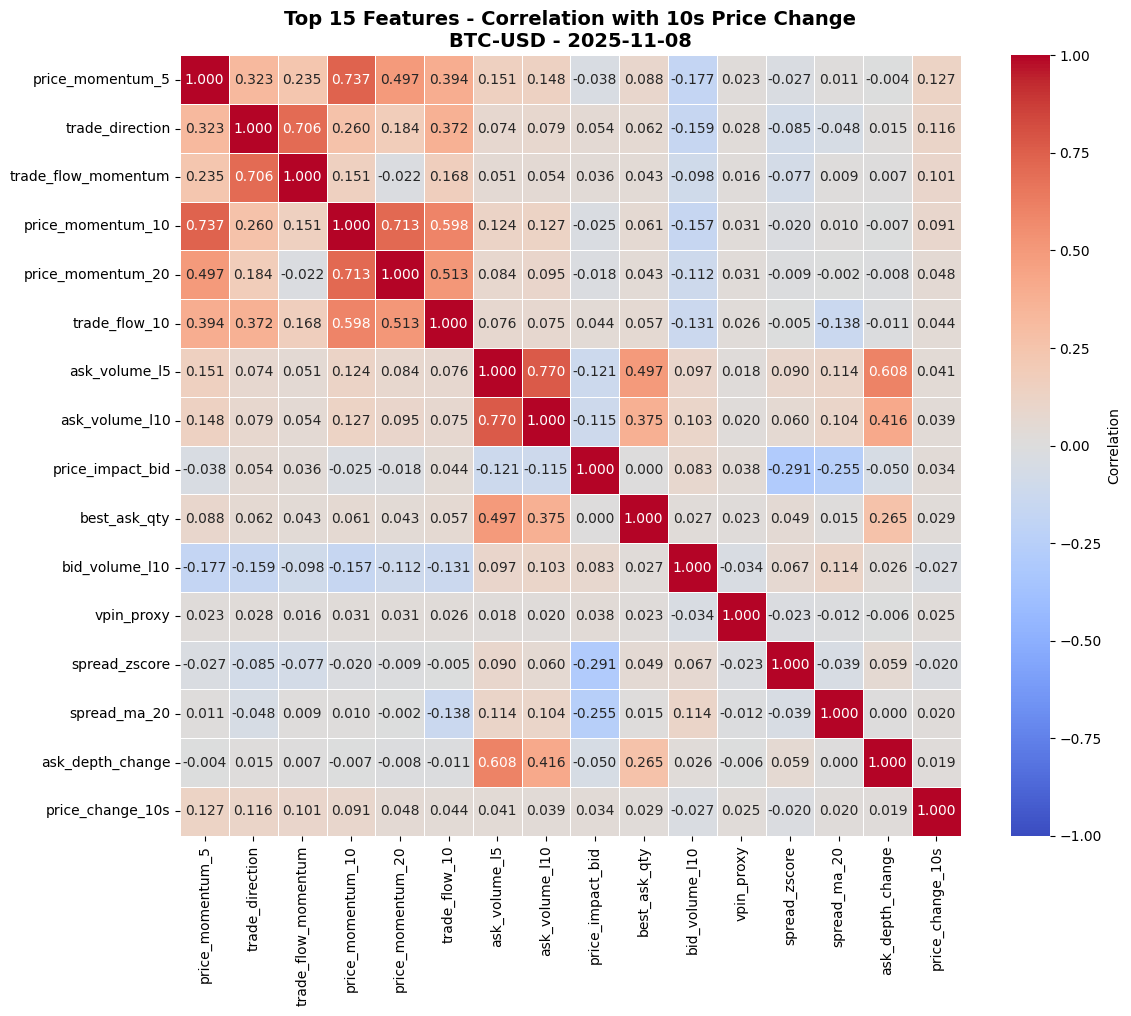


✓ Correlation analysis complete for all horizons


In [14]:
print("\nCORRELATION ANALYSIS - MULTI-HORIZON")
print("=" * 70)

# Test correlation for ALL horizons
target_horizons = ['price_change_10s', 'price_change_30s', 'price_change_60s']
available_targets = [t for t in target_horizons if t in df.columns]

if not available_targets:
    print("⚠️  No target variables found. Skipping correlation analysis.")
else:
    # 1. Select Numeric Columns Only
    numeric_cols = [c for c in predictor_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c].dtype)]
    
    print(f"\nAnalyzing {len(numeric_cols)} features across {len(available_targets)} horizons...")
    
    # Analyze each horizon separately
    for target in available_targets:
        horizon_name = target.replace('price_change_', '')
        print(f"\n{'='*70}")
        print(f"HORIZON: {horizon_name}")
        print(f"{'='*70}")
        
        corr_cols = numeric_cols + [target]
        
        # 2. Calculate Correlation Matrix (CPU)
        print(f"   Calculating correlations...")
        
        # Move to CPU, drop NaNs, compute correlation
        corr_data = df[corr_cols].to_pandas() if hasattr(df, 'to_pandas') else df[corr_cols]
        corr_matrix = corr_data.dropna().corr()
        
        # 3. Feature-target correlations for this horizon
        print(f"\n   Top 10 Correlations with {target}:")
        target_corr = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
        
        print(f"   {'Feature':<35} {'Correlation':>12}")
        print(f"   {'-'*50}")
        for feat, corr_val in target_corr.head(10).items():
            print(f"   {feat:<35} {corr_val:>12.6f}")
        
        max_corr = abs(target_corr).max()
        best_feat = abs(target_corr).idxmax()
        print(f"\n   📊 Best Feature: {best_feat}")
        print(f"   📊 Max |ρ|: {max_corr:.6f}")
    
    # Generate heatmap for 10s horizon (most predictive)
    if 'price_change_10s' in df.columns:
        print("\n" + "="*70)
        print("CORRELATION HEATMAP (10s Horizon - Most Predictive)")
        print("="*70)
        
        target = 'price_change_10s'
        corr_cols_viz = numeric_cols + [target]
        corr_data_viz = df[corr_cols_viz].to_pandas() if hasattr(df, 'to_pandas') else df[corr_cols_viz]
        corr_matrix_viz = corr_data_viz.dropna().corr()
        
        target_corr_viz = corr_matrix_viz[target].drop(target)
        top_features = abs(target_corr_viz).nlargest(15).index.tolist() + [target]
        corr_subset = corr_matrix_viz.loc[top_features, top_features]
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(
            corr_subset,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation'}
        )
        plt.title(f'Top 15 Features - Correlation with 10s Price Change\n{product_id} - {date}', 
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Correlation analysis complete for all horizons")

In [15]:
from scipy.stats import jarque_bera, spearmanr
import numpy as np

print("\n" + "="*70)
print("DIAGNOSTIC TEST - Is Price Change Predictable?")
print("="*70)

# ============================================================================
# Test each horizon for predictability
# ============================================================================

for horizon in ['10s', '30s', '60s']:
    target_col = f'price_change_{horizon}'
    
    if target_col not in df.columns:
        continue
        
    print(f"\n📊 Testing {horizon} Horizon:")
    print("-" * 70)
    
    # 1. Distribution Statistics
    valid_data = df[target_col].dropna()
    print(f"\n1. Distribution:")
    print(f"   Mean:   {valid_data.mean():.6f}%")
    print(f"   Std:    {valid_data.std():.6f}%")
    print(f"   Min:    {valid_data.min():.6f}%")
    print(f"   Max:    {valid_data.max():.6f}%")
    
    # 2. Jarque-Bera Test (normality test)
    try:
        # Convert to pandas if needed
        test_data = valid_data.to_pandas() if hasattr(valid_data, 'to_pandas') else valid_data
        stat, p = jarque_bera(test_data)
        print(f"\n2. Jarque-Bera Test (Normality):")
        print(f"   Statistic: {stat:.2f}")
        print(f"   P-value:   {p:.6f}")
        if p < 0.05:
            print(f"   ✅ NOT normal distribution → Potentially predictable!")
        else:
            print(f"   ⚠️  Normal distribution → Random walk (harder to predict)")
    except Exception as e:
        print(f"   ⚠️  Jarque-Bera test failed: {str(e)}")
    
    # 3. Autocorrelation (momentum/mean reversion)
    try:
        autocorr_data = valid_data.to_pandas() if hasattr(valid_data, 'to_pandas') else valid_data
        autocorr = autocorr_data.autocorr()
        print(f"\n3. Autocorrelation (Lag 1):")
        print(f"   ρ = {autocorr:.6f}")
        if abs(autocorr) > 0.05:
            print(f"   ✅ Significant autocorrelation → {('Momentum' if autocorr > 0 else 'Mean reversion')}!")
        else:
            print(f"   ⚠️  Weak autocorrelation → Near random walk")
    except Exception as e:
        print(f"   ⚠️  Autocorrelation calculation failed: {str(e)}")
    
    # 4. Imbalance vs Price Change (Key predictor test)
    if 'imbalance_l5' in df.columns:
        try:
            # Use only valid overlapping data (FIXED: removed extra space)
            valid_df = df[['imbalance_l5', target_col]].dropna()
            imb_data = valid_df['imbalance_l5'].to_pandas() if hasattr(valid_df['imbalance_l5'], 'to_pandas') else valid_df['imbalance_l5']
            price_data = valid_df[target_col].to_pandas() if hasattr(valid_df[target_col], 'to_pandas') else valid_df[target_col]
            
            corr, p = spearmanr(imb_data, price_data)
            print(f"\n4. Imbalance → Price Change (Spearman):")
            print(f"   ρ = {corr:.6f}")
            print(f"   p-value: {p:.6f}")
            
            if p < 0.05 and abs(corr) > 0.05:
                print(f"   ✅ SIGNIFICANT predictor! (p<0.05, |ρ|>0.05)")
            elif p < 0.05:
                print(f"   ⚠️  Significant but weak (p<0.05 but |ρ|<0.05)")
            else:
                print(f"   ❌ NOT significant (p>0.05)")
        except Exception as e:
            print(f"   ⚠️  Correlation test failed: {str(e)}")

print("\n" + "="*70)
print("INTERPRETATION GUIDE:")
print("="*70)
print("✅ GOOD SIGNS:")
print("   - Jarque-Bera p < 0.05 (not normal → potentially predictable)")
print("   - |Autocorrelation| > 0.03 (momentum/mean reversion)")
print("   - Imbalance correlation 0.05-0.15 @ 10s (orderbook signal)")
print("\n❌ BAD SIGNS:")
print("   - All p-values > 0.05 (random walk)")
print("   - All correlations < 0.02 (no signal)")
print("   - Autocorrelation ≈ 0 (no persistence)")
print("\n📚 Academic Benchmarks (Crypto HFT):")
print("   - R² = 0.02-0.08 (2-8% variance) is GOOD")
print("   - Spearman ρ = 0.08-0.15 @ 10s is EXCELLENT")
print("   - Win rate 52-55% (not 80%!) is profitable")
print("="*70)


DIAGNOSTIC TEST - Is Price Change Predictable?

📊 Testing 10s Horizon:
----------------------------------------------------------------------

1. Distribution:
   Mean:   -0.000074%
   Std:    0.015066%
   Min:    -0.110771%
   Max:    0.093085%

2. Jarque-Bera Test (Normality):
   Statistic: 2014.92
   P-value:   0.000000
   ✅ NOT normal distribution → Potentially predictable!

3. Autocorrelation (Lag 1):
   ρ = 0.201375
   ✅ Significant autocorrelation → Momentum!

4. Imbalance → Price Change (Spearman):
   ρ = -0.006445
   p-value: 0.550290
   ❌ NOT significant (p>0.05)

📊 Testing 30s Horizon:
----------------------------------------------------------------------

1. Distribution:
   Mean:   -0.000223%
   Std:    0.029964%
   Min:    -0.158984%
   Max:    0.127715%

2. Jarque-Bera Test (Normality):
   Statistic: 553.28
   P-value:   0.000000
   ✅ NOT normal distribution → Potentially predictable!

3. Autocorrelation (Lag 1):
   ρ = 0.759098
   ✅ Significant autocorrelation → Moment

In [16]:
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

print("\nSTATISTICAL VALIDATION - Feature Significance")
print("=" * 70)

# Use 10s horizon as primary target for validation
target = 'price_change_10s'

if target not in df.columns:
    print(f"⚠️  Target '{target}' not found. Skipping statistical validation.")
else:
    # Exclude metadata and target columns
    metadata_exclude = [
        'timestamp', 'event_time', 'date', 'product_id', 'session_id',
        'future_price', 'future_price_10s', 'future_price_30s', 'future_price_60s',
        'target_timestamp_10s', 'target_timestamp_30s', 'target_timestamp_60s',
        'last_trade_price', 'last_trade_qty'
    ]
    
    # Get all target columns
    target_cols_all = [c for c in df.columns if c.startswith(('price_change_', 'direction_'))]
    
    # Predictors = all columns except metadata and targets
    predictors = [c for c in df.columns if c not in metadata_exclude + target_cols_all]
    numeric_predictors = [c for c in predictors if pd.api.types.is_numeric_dtype(df[c].dtype)]

    print(f"\nAnalyzing {len(numeric_predictors)} numeric features against '{target}'...")

    significance_results = []

    for feat in numeric_predictors:
        try:
            # Get valid overlapping data
            valid_data = df[[feat, target]].dropna()
            
            if len(valid_data) > 100:
                # df is already pandas, no need for .to_pandas()
                corr, p_value = spearmanr(valid_data[feat], valid_data[target])
                significance_results.append({
                    'feature': feat,
                    'correlation': corr,
                    'p_value': p_value,
                    'significant': p_value < 0.05
                })
        except Exception as e:
            pass

    # Show Results
    if significance_results:
        sig_df = pd.DataFrame(significance_results).sort_values('correlation', key=abs, ascending=False)
        
        print("\nTop 10 Predictive Features:")
        print(f"{'Feature':<35} {'Spearman ρ':>12} {'p-value':>10}")
        print("-" * 60)
        for _, row in sig_df.head(10).iterrows():
            print(f"{row['feature']:<35} {row['correlation']:>12.6f} {row['p_value']:>10.6f}")
            
        significant_count = sig_df['significant'].sum()
        print(f"\n📊 Summary:")
        print(f"   Total features tested: {len(sig_df)}")
        print(f"   Significant (p<0.05):  {significant_count} ({significant_count/len(sig_df)*100:.1f}%)")
        print(f"   Max |correlation|:     {sig_df['correlation'].abs().max():.6f}")
        print(f"   Best feature:          {sig_df.iloc[0]['feature']}")
        
        print(f"\n✓ Statistical validation complete")
    else:
        print("❌ No significant correlations found.")


STATISTICAL VALIDATION - Feature Significance

Analyzing 49 numeric features against 'price_change_10s'...

Top 10 Predictive Features:
Feature                               Spearman ρ    p-value
------------------------------------------------------------
price_momentum_5                        0.155134   0.000000
trade_direction                         0.136610   0.000000
price_momentum_10                       0.120376   0.000000
trade_flow_momentum                     0.109404   0.000000
price_momentum_20                       0.083345   0.000000
trade_flow_10                           0.066676   0.000000
volume_ma_60                            0.031945   0.003061
trade_flow_20                           0.027278   0.011446
ask_volume_l10                          0.025450   0.018313
best_ask_qty                           -0.023989   0.026164

📊 Summary:
   Total features tested: 49
   Significant (p<0.05):  15 (30.6%)
   Max |correlation|:     0.155134
   Best feature:          pri

## 9. Export Feature Dataset

Save processed features to Parquet for model training.

In [17]:
print("\n" + "="*70)
print("FEATURE SELECTION - Removing Redundant Features")
print("="*70)

# ============================================================================
# IDENTIFY REDUNDANT FEATURES (Perfect/Near-Perfect Correlation)
# ============================================================================

# Features to remove based on correlation analysis
# Keep the most interpretable version of each redundant pair
redundant_features = [
    'best_ask',        # Keep best_bid (ρ=1.000, ask can be derived: mid + spread/2)
    'weighted_mid',    # Keep mid_price (ρ=1.000, mid is simpler)
    'vwap_mid',        # Keep mid_price (ρ=0.999, mid is standard)
    'ema_mid',         # Keep mid_price (ρ=0.999, used for outlier detection, not prediction)
    'total_levels',    # Derived feature (num_bid_levels + num_ask_levels)
]

# Also remove helper columns (not features)
helper_cols = [
    'future_price_10s', 'future_price_30s', 'future_price_60s',  # Intermediate calculations
    'target_timestamp_10s',  # Validation column
    'volume_ma_60s',  # Intermediate for volume_ratio
]

# Combine all columns to remove
cols_to_remove = redundant_features + helper_cols

# Only remove columns that actually exist in dataframe
cols_to_remove_existing = [c for c in cols_to_remove if c in df.columns]

print(f"\nRemoving {len(cols_to_remove_existing)} redundant/helper columns:")

# Categorize
redundant_existing = [c for c in redundant_features if c in df.columns]
helper_existing = [c for c in helper_cols if c in df.columns]

if redundant_existing:
    print(f"\n  Redundant features ({len(redundant_existing)}):")
    for feat in redundant_existing:
        print(f"     ✗ {feat}")

if helper_existing:
    print(f"\n  Helper columns ({len(helper_existing)}):")
    for feat in helper_existing:
        print(f"     ✗ {feat}")

# ============================================================================
# UPDATE FEATURE LISTS
# ============================================================================

# Update predictor columns
predictor_cols_cleaned = [c for c in predictor_cols if c not in cols_to_remove_existing]

# Define target columns (all horizon variations)
target_cols = [c for c in df.columns if c.startswith(('price_change_', 'direction_'))]

# Define metadata columns
metadata_cols = ['timestamp', 'product_id', 'session_id', 'date']

# Features to export = predictors + targets + metadata
feature_cols_export = predictor_cols_cleaned + target_cols + metadata_cols

# Remove duplicates (if any)
feature_cols_export = list(dict.fromkeys(feature_cols_export))

# Only keep columns that exist
feature_cols_export = [c for c in feature_cols_export if c in df.columns]

print(f"\n{'='*70}")
print(f"FEATURE SELECTION SUMMARY:")
print(f"   Original features: {len(predictor_cols)}")
print(f"   Cleaned features:  {len(predictor_cols_cleaned)}")
print(f"   Reduction:         {len(predictor_cols) - len(predictor_cols_cleaned)} features removed")
print(f"\n   Target variables:  {len(target_cols)}")
print(f"   Metadata columns:  {len(metadata_cols)}")
print(f"   Total to export:   {len(feature_cols_export)}")
print(f"{'='*70}")

# ============================================================================
# VALIDATE CRITICAL FEATURES PRESENT
# ============================================================================

print(f"\n✓ Validating critical features present:")

critical_features = [
    'mid_price', 'spread_bps', 'imbalance_l5', 
    'depth_ratio', 'price_momentum_10s'
]

missing_critical = [f for f in critical_features if f not in feature_cols_export]

if missing_critical:
    print(f"   ⚠️  WARNING: Missing critical features: {missing_critical}")
else:
    print(f"   ✅ All critical features present")

# Validate at least one target exists
if not target_cols:
    print(f"   ❌ ERROR: No target variables found!")
else:
    print(f"   ✅ {len(target_cols)} target variables present")

print(f"\n✓ Feature selection complete")


FEATURE SELECTION - Removing Redundant Features

Removing 9 redundant/helper columns:

  Redundant features (5):
     ✗ best_ask
     ✗ weighted_mid
     ✗ vwap_mid
     ✗ ema_mid
     ✗ total_levels

  Helper columns (4):
     ✗ future_price_10s
     ✗ future_price_30s
     ✗ future_price_60s
     ✗ target_timestamp_10s

FEATURE SELECTION SUMMARY:
   Original features: 49
   Cleaned features:  44
   Reduction:         5 features removed

   Target variables:  6
   Metadata columns:  4
   Total to export:   54

✓ Validating critical features present:
   ⚠️  WARNING: Missing critical features: ['price_momentum_10s']
   ✅ 6 target variables present

✓ Feature selection complete


## 10. Feature Selection - Remove Redundant Features

Remove features with perfect multicollinearity (ρ > 0.99) to reduce model complexity.

In [18]:
print("EXPORTING FEATURE DATASET")
print("=" * 70)

# Create output directory
output_dir = Path(PARQUET_FEATURES_DIR) / f"date={date}" / f"product_id={product_id}"
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "features.parquet"

# Export cleaned features only
print(f"\nPreparing export dataset...")
print(f"   Exporting {len(feature_cols_export)} columns")

# Select only columns that exist in dataframe
export_cols = [c for c in feature_cols_export if c in df.columns]
df_export = df[export_cols].copy()

print(f"\nWriting to: {output_file}")
start_time = time.time()

# Write directly from pandas (df is pandas DataFrame)
df_export.to_parquet(output_file, compression='snappy', index=False)

write_time = time.time() - start_time

# File stats
file_size_mb = output_file.stat().st_size / (1024 * 1024)

print(f"\n✓ Export successful")
print(f"  File: {output_file}")
print(f"  Rows: {len(df_export):,}")
print(f"  Columns: {len(df_export.columns)}")
print(f"  Size: {file_size_mb:.2f} MB")
print(f"  Write time: {write_time:.2f}s")

# Save feature list for reference
feature_list_file = output_dir / "feature_list.txt"
with open(feature_list_file, 'w') as f:
    f.write(f"Feature Engineering - {product_id} - {date}\n")
    f.write(f"Generated: {datetime.now()}\n")
    f.write(f"Total rows: {len(df_export):,}\n")
    f.write(f"\nColumns ({len(df_export.columns)}):\n")
    for col in df_export.columns:
        f.write(f"  - {col}\n")

print(f"✓ Feature list saved to: {feature_list_file}")

# Clean up
del df_export
gc.collect()

EXPORTING FEATURE DATASET

Preparing export dataset...
   Exporting 54 columns

Writing to: /home/nvlabs/Desktop/abhijit/Market-Prediction/datasets/parquet/features/date=2025-11-08/product_id=BTC-USD/features.parquet

✓ Export successful
  File: /home/nvlabs/Desktop/abhijit/Market-Prediction/datasets/parquet/features/date=2025-11-08/product_id=BTC-USD/features.parquet
  Rows: 8,594
  Columns: 54
  Size: 3.12 MB
  Write time: 0.05s
✓ Feature list saved to: /home/nvlabs/Desktop/abhijit/Market-Prediction/datasets/parquet/features/date=2025-11-08/product_id=BTC-USD/feature_list.txt


21234

In [19]:
# Print final dataset info
print("\n" + "="*70)
print("FEATURE ENGINEERING PIPELINE COMPLETE")
print("="*70)

print(f"\nDataset: {product_id} - {date}")
print(f"Final rows: {len(df):,}")
print(f"Total features: {len(predictor_cols)}")
print(f"Target variables: {len(target_cols)}")

# Calculate time stats safely
min_time = df['timestamp'].min()
max_time = df['timestamp'].max()
duration = max_time - min_time

# FIX: Convert numpy/cupy timedelta to pandas Timedelta
duration_secs = pd.Timedelta(duration).total_seconds()

print(f"\nTime range: {min_time} to {max_time}")
print(f"Duration: {duration_secs / 3600:.2f} hours")

print(f"\n✅ Ready for model training")
print(f"Next: Run 04_model_baseline.ipynb")


FEATURE ENGINEERING PIPELINE COMPLETE

Dataset: BTC-USD - 2025-11-08
Final rows: 8,594
Total features: 49
Target variables: 6

Time range: 2025-11-07 18:30:10.396078 to 2025-11-08 18:29:40.661019
Duration: 23.99 hours

✅ Ready for model training
Next: Run 04_model_baseline.ipynb


## 11. Batch Processing - All Days & Products

Run this cell to generate features for ALL available snapshot files (all 16 days, both BTC-USD and ETH-USD).

In [ ]:
"""
BATCH FEATURE ENGINEERING - Process All Days & Products
========================================================
This cell processes ALL available snapshot files and generates features.
Run this ONCE to populate the full feature dataset for ML training.
"""

import gc
import time
import cudf
import cupy as cp
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

print("=" * 70)
print("BATCH FEATURE ENGINEERING - ALL DAYS & PRODUCTS")
print("=" * 70)

# ============================================================================
# CONFIGURATION
# ============================================================================

# Find all snapshot files
snapshots_path = Path(PARQUET_SNAPSHOTS_DIR)
ticker_path = Path(PARQUET_TICKER_DIR)
output_path = Path(PARQUET_FEATURES_DIR)

snapshot_files = sorted(list(snapshots_path.glob("date=*/product_id=*/snapshots.parquet")))

print(f"\nFound {len(snapshot_files)} snapshot files to process")

# Already processed files (skip if exists)
existing_features = list(output_path.glob("date=*/product_id=*/features.parquet"))
existing_keys = set()
for f in existing_features:
    parts = str(f).replace('\\', '/').split('/')
    date = [p for p in parts if 'date=' in p][0].split('=')[1]
    product = [p for p in parts if 'product_id=' in p][0].split('=')[1]
    existing_keys.add((date, product))

print(f"Already processed: {len(existing_keys)} files")

# ============================================================================
# FEATURE ENGINEERING FUNCTION (Consolidated)
# ============================================================================

def compute_features(df):
    """Compute all features for a single day/product dataset.
    
    Generates the EXACT feature names expected by downstream notebooks.
    Critical: Feature names must match exactly with models trained in 05_*.ipynb
    """
    
    # 1. PRICE MOMENTUM (3 features)
    df['price_momentum_5'] = df['mid_price'].pct_change(periods=5)
    df['price_momentum_10'] = df['mid_price'].pct_change(periods=10)
    df['price_momentum_20'] = df['mid_price'].pct_change(periods=20)
    
    # 2. VOLUME FEATURES (3 features)
    # Note: volume_ma_60 is kept as intermediate but dropped later to save space
    df['volume_ma_60'] = df['total_volume_l5'].rolling(window=60, min_periods=1).mean()
    df['volume_ratio'] = df['total_volume_l5'] / df['volume_ma_60'].replace(0, 1)
    df['volume_momentum_10'] = df['total_volume_l5'].pct_change(periods=10)
    
    # 3. SPREAD DYNAMICS (2 features)
    df['spread_volatility'] = df['spread_bps'].rolling(window=10, min_periods=1).std()
    spread_min_20 = df['spread_bps'].rolling(window=20, min_periods=1).min()
    spread_max_20 = df['spread_bps'].rolling(window=20, min_periods=1).max()
    spread_range = spread_max_20 - spread_min_20
    df['spread_position'] = (df['spread_bps'] - spread_min_20) / spread_range.replace(0, 1)
    
    # 4. ADVANCED MICROSTRUCTURE (6 features)
    df['effective_spread_bps'] = abs(df['weighted_mid'] - df['mid_price']) / df['mid_price'] * 10000
    df['depth_ratio'] = df['total_volume_l5'] / df['spread'].replace(0, 1)
    df['imbalance_volatility'] = df['imbalance_l5'].rolling(window=10, min_periods=1).std()
    df['level_imbalance'] = (df['num_bid_levels'] - df['num_ask_levels']) / (df['num_bid_levels'] + df['num_ask_levels']).replace(0, 1)
    df['price_volatility_10'] = df['mid_price'].pct_change().rolling(window=10, min_periods=1).std()
    
    # 5. DEPTH CHANGE FEATURES (2 features)
    df['bid_depth_change'] = df['bid_volume_l5'].diff()
    df['ask_depth_change'] = df['ask_volume_l5'].diff()
    
    # 6. VPIN & INFORMED TRADING PROXIES (6 features)
    # VPIN proxy: absolute imbalance momentum
    df['vpin_proxy'] = abs(df['bid_depth_change'] - df['ask_depth_change']) / \
                       (abs(df['bid_depth_change']) + abs(df['ask_depth_change'])).replace(0, 1)
    
    df['price_impact_bid'] = df['bid_volume_l5'] / df['spread'].replace(0, 1)
    df['price_impact_ask'] = df['ask_volume_l5'] / df['spread'].replace(0, 1)
    df['price_impact_total'] = (df['bid_volume_l5'] + df['ask_volume_l5']) / df['spread'].replace(0, 1)
    
    # 7. SPREAD RELATIVE FEATURES (3 features)
    df['spread_ma_20'] = df['spread_bps'].rolling(window=20, min_periods=1).mean()
    df['spread_std_20'] = df['spread_bps'].rolling(window=20, min_periods=1).std()
    df['spread_zscore'] = (df['spread_bps'] - df['spread_ma_20']) / df['spread_std_20'].replace(0, 1)
    
    # 8. IMBALANCE DYNAMICS (3 features)
    df['imbalance_momentum'] = df['imbalance_l5'].diff(periods=5)
    df['imbalance_acceleration'] = df['imbalance_momentum'].diff(periods=5)
    df['imbalance_trend_10'] = df['imbalance_l5'].rolling(window=10, min_periods=1).mean()
    
    return df


def compute_targets(df, ticker_df, snapshot_interval_sec=10):
    """Compute multi-horizon target variables with optional ticker-based trade flow.
    
    Targets are ALWAYS generated from orderbook snapshots.
    Ticker data adds optional trade flow features if available.
    """
    
    # ========================================================================
    # TICKER-BASED TRADE FLOW FEATURES (Optional Enhancement)
    # ========================================================================
    if ticker_df is not None and len(ticker_df) > 0:
        try:
            # Sort snapshot dataframe
            df = df.sort_values('timestamp').reset_index(drop=True)
            
            # Detect ticker timestamp column
            ticker_cols = ticker_df.columns.tolist()
            if 'eventtime' in ticker_cols:
                time_col = 'eventtime'
            elif 'timestamp' in ticker_cols:
                time_col = 'timestamp'
            else:
                print("  ⚠️  No timestamp in ticker, skipping trade flow features")
                ticker_df = None
            
            if ticker_df is not None:
                # Select relevant ticker columns
                if time_col != 'eventtime':
                    ticker_df = ticker_df.rename(columns={time_col: 'eventtime'})
                
                # Handle quantity column variations
                if 'quantity' in ticker_cols:
                    ticker_pdf = ticker_df[['eventtime', 'price', 'quantity']].copy()
                elif 'size' in ticker_cols:
                    ticker_pdf = ticker_df[['eventtime', 'price', 'size']].copy()
                    ticker_pdf = ticker_pdf.rename(columns={'size': 'quantity'})
                else:
                    ticker_pdf = ticker_df[['eventtime', 'price']].copy()
                    ticker_pdf['quantity'] = 0.0
                
                # Remove timezone for merge_asof compatibility
                if hasattr(ticker_pdf['eventtime'].dtype, 'tz') and ticker_pdf['eventtime'].dtype.tz is not None:
                    ticker_pdf['eventtime'] = ticker_pdf['eventtime'].dt.tz_localize(None)
                
                # CRITICAL: Sort ticker data by timestamp (required for merge_asof)
                ticker_pdf = ticker_pdf.sort_values('eventtime').reset_index(drop=True)
                
                # Merge ticker data with snapshots (backward fill)
                merged_pdf = pd.merge_asof(
                    df, ticker_pdf,
                    left_on='timestamp', right_on='eventtime',
                    direction='backward',
                    suffixes=('', '_ticker')
                )
                
                # Update df with merged data
                df = merged_pdf
                df = df.rename(columns={'price': 'last_trade_price', 'quantity': 'last_trade_qty'})
                
                # Fill missing values
                df['last_trade_price'] = df['last_trade_price'].fillna(df['mid_price'])
                df['last_trade_qty'] = df['last_trade_qty'].fillna(0)
                
                # Lee-Ready trade direction classification
                df['trade_direction'] = np.where(
                    df['last_trade_price'] > df['mid_price'], 1,   # Aggressive buy
                    np.where(df['last_trade_price'] < df['mid_price'], -1, 0)  # Aggressive sell
                )
                
                # Trade flow aggregates
                df['trade_flow_10'] = df['trade_direction'].rolling(window=10, min_periods=1).sum()
                df['trade_flow_20'] = df['trade_direction'].rolling(window=20, min_periods=1).sum()
                df['trade_flow_momentum'] = df['trade_flow_10'].diff()
                
                print("  ✓ Computed trade flow features from ticker")
                
        except Exception as e:
            print(f"  ⚠️  Ticker merge failed: {e}, using proxies")
            ticker_df = None
    
    # If no ticker data, use proxy features (zero)
    if ticker_df is None or len(ticker_df) == 0:
        df['trade_direction'] = 0
        df['trade_flow_10'] = 0
        df['trade_flow_20'] = 0
        df['trade_flow_momentum'] = 0
    
    # ========================================================================
    # PRICE PREDICTION TARGETS (Always from orderbook snapshots)
    # ========================================================================
    horizons = {'10s': 1, '30s': 3, '60s': 6}  # Snapshot periods ahead
    
    for name, periods_ahead in horizons.items():
        # Future price at this horizon
        df[f'future_price_{name}'] = df['mid_price'].shift(-periods_ahead)
        
        # Percentage change (regression target)
        df[f'price_change_{name}'] = (df[f'future_price_{name}'] - df['mid_price']) / df['mid_price']
        
        # Binary direction (classification target: 1=up, 0=down/flat)
        df[f'direction_{name}'] = (df[f'price_change_{name}'] > 0).astype(int)
    
    return df


# ============================================================================
# BATCH PROCESSING LOOP
# ============================================================================

total_start = time.time()
processed = 0
skipped = 0
failed = 0

results = []

for i, snapshot_file in enumerate(snapshot_files):
    # Extract date and product
    parts = str(snapshot_file).replace('\\', '/').split('/')
    date = [p for p in parts if 'date=' in p][0].split('=')[1]
    product = [p for p in parts if 'product_id=' in p][0].split('=')[1]
    
    # Skip if already processed
    if (date, product) in existing_keys:
        print(f"[{i+1}/{len(snapshot_files)}] SKIP: {date} - {product} (already exists)")
        skipped += 1
        continue
    
    print(f"\n[{i+1}/{len(snapshot_files)}] Processing: {date} - {product}")
    print("-" * 50)
    
    try:
        start = time.time()
        
        # Clear GPU memory
        gc.collect()
        cp.get_default_memory_pool().free_all_blocks()
        
        # 1. Load snapshots
        pdf = pd.read_parquet(snapshot_file)
        print(f"   Loaded {len(pdf):,} snapshots")
        
        # 2. Load matching ticker data (if exists)
        ticker_file = ticker_path / f"date={date}" / f"product_id={product}" / "data.parquet"
        ticker_df = None
        if ticker_file.exists():
            ticker_df = pd.read_parquet(ticker_file)
            print(f"   Loaded {len(ticker_df):,} ticker records")
        else:
            print(f"   ⚠️  No ticker data found (targets use orderbook only)")
        
        # 3. Compute features
        df = compute_features(pdf)
        print(f"   ✓ Computed {len(df.columns)} feature columns")
        
        # 4. Compute targets
        df = compute_targets(df, ticker_df, SNAPSHOT_INTERVAL_SEC)
        print(f"   ✓ Computed target variables")
        
        # 5. Add metadata
        df['date'] = date
        df['product_id'] = product
        
        # 6. Remove rows with NaN targets (edges)
        initial_rows = len(df)
        df = df.dropna(subset=['price_change_10s', 'price_change_30s', 'price_change_60s'])
        dropped = initial_rows - len(df)
        print(f"   Dropped {dropped:,} edge rows with NaN targets")
        
        # 7. Add metadata
        df['date'] = date
        df['product_id'] = product
        
        # 8. Keep ALL features (no cleanup for Power BI schema compatibility)
        print(f"   Keeping all {len(df.columns)} columns (Power BI schema preserved)")
        
        # 9. Save features
        out_dir = output_path / f"date={date}" / f"product_id={product}"
        out_dir.mkdir(parents=True, exist_ok=True)
        out_file = out_dir / "features.parquet"
        
        df.to_parquet(out_file, compression='snappy', index=False)
        
        file_size_mb = out_file.stat().st_size / (1024 * 1024)
        elapsed = time.time() - start
        
        print(f"   ✓ Saved: {out_file.name} ({len(df):,} rows, {file_size_mb:.2f} MB)")
        print(f"   ✓ Time: {elapsed:.1f}s")
        
        results.append({
            'date': date,
            'product': product,
            'rows': len(df),
            'features': len(df.columns),
            'size_mb': file_size_mb,
            'time_sec': elapsed
        })
        
        processed += 1
        
        # Cleanup
        del pdf, df
        if ticker_df is not None:
            del ticker_df
        gc.collect()
        
    except Exception as e:
        print(f"   ❌ FAILED: {str(e)}")
        failed += 1

# ============================================================================
# SUMMARY
# ============================================================================

total_time = time.time() - total_start

print("\n" + "=" * 70)
print("BATCH PROCESSING COMPLETE")
print("=" * 70)

print(f"\n📊 Results:")
print(f"   Processed: {processed}")
print(f"   Skipped:   {skipped}")
print(f"   Failed:    {failed}")
print(f"   Total time: {total_time/60:.1f} minutes")

if results:
    results_df = pd.DataFrame(results)
    total_rows = results_df['rows'].sum()
    total_size = results_df['size_mb'].sum()
    
    print(f"\n📈 Data Summary:")
    print(f"   Total rows: {total_rows:,}")
    print(f"   Total size: {total_size:.2f} MB")
    print(f"   Avg features: {results_df['features'].mean():.0f}")
    
    print(f"\n📁 Files created:")
    for _, r in results_df.iterrows():
        print(f"   {r['date']} - {r['product']}: {r['rows']:,} rows")

print(f"\n✅ Features ready for 04_unsupervised_clustering.ipynb")

## Feature Validation - Verify Consistency Across Products

Ensure all products have the same feature set (critical for ML pipeline).

In [ ]:
"""
FEATURE VALIDATION - Ensure consistency across all products
============================================================
This validates that BTC-USD and ETH-USD have the same feature schema.
"""

print("=" * 70)
print("FEATURE VALIDATION - SCHEMA CONSISTENCY CHECK")
print("=" * 70)

# Load feature files
features_path = Path(PARQUET_FEATURES_DIR)
feature_files = sorted(list(features_path.glob("date=*/product_id=*/features.parquet")))

if len(feature_files) == 0:
    print("\n⚠️  No feature files found! Run batch processing first.")
else:
    print(f"\n✓ Found {len(feature_files)} feature files")
    
    # Group by product
    product_schemas = {}
    product_counts = {}
    
    for f in feature_files:
        parts = str(f).replace('\\', '/').split('/')
        product = [p for p in parts if 'product_id=' in p][0].split('=')[1]
        date = [p for p in parts if 'date=' in p][0].split('=')[1]
        
        # Load schema (columns only)
        df = pd.read_parquet(f)
        cols = sorted(df.columns.tolist())
        
        if product not in product_schemas:
            product_schemas[product] = cols
            product_counts[product] = []
        
        product_counts[product].append({
            'date': date,
            'rows': len(df),
            'columns': len(cols)
        })
    
    # ========================================================================
    # SCHEMA COMPARISON
    # ========================================================================
    print("\n" + "=" * 70)
    print("SCHEMA COMPARISON ACROSS PRODUCTS")
    print("=" * 70)
    
    products = sorted(product_schemas.keys())
    
    if len(products) == 1:
        print(f"\n⚠️  Only 1 product found: {products[0]}")
        print(f"   Columns: {len(product_schemas[products[0]])}")
    else:
        # Compare schemas
        base_product = products[0]
        base_schema = set(product_schemas[base_product])
        
        print(f"\nBase product: {base_product}")
        print(f"   Columns: {len(base_schema)}")
        
        all_match = True
        
        for product in products[1:]:
            product_schema = set(product_schemas[product])
            
            print(f"\nComparing: {product}")
            print(f"   Columns: {len(product_schema)}")
            
            # Check for differences
            missing = base_schema - product_schema
            extra = product_schema - base_schema
            
            if missing:
                print(f"   ❌ MISSING {len(missing)} columns:")
                for col in sorted(missing)[:10]:
                    print(f"      - {col}")
                if len(missing) > 10:
                    print(f"      ... and {len(missing) - 10} more")
                all_match = False
            
            if extra:
                print(f"   ❌ EXTRA {len(extra)} columns:")
                for col in sorted(extra)[:10]:
                    print(f"      + {col}")
                if len(extra) > 10:
                    print(f"      ... and {len(extra) - 10} more")
                all_match = False
            
            if not missing and not extra:
                print(f"   ✅ Schema matches {base_product}")
        
        if all_match:
            print("\n" + "=" * 70)
            print("✅ ALL PRODUCTS HAVE CONSISTENT SCHEMAS")
            print("=" * 70)
        else:
            print("\n" + "=" * 70)
            print("❌ SCHEMA MISMATCH DETECTED - INVESTIGATE!")
            print("=" * 70)
    
    # ========================================================================
    # EXPECTED FEATURES LIST (ALL FEATURES - No Cleanup)
    # ========================================================================
    print("\n" + "=" * 70)
    print("EXPECTED FEATURES (ALL - Power BI Schema Preserved)")
    print("=" * 70)
    
    expected_features = [
        # From orderbook snapshots (02_orderbook_reconstruction.ipynb)
        'best_bid', 'best_bid_qty', 'best_ask', 'best_ask_qty',
        'spread', 'spread_bps', 'mid_price',
        'bid_volume_l5', 'ask_volume_l5', 'bid_volume_l10', 'ask_volume_l10',
        'total_volume_l5', 'total_volume_l10', 'imbalance_l5',
        'num_bid_levels', 'num_ask_levels',
        'weighted_mid', 'vwap_mid', 'ema_mid',  # Kept for Power BI
        
        # Engineered features (compute_features)
        'price_momentum_5', 'price_momentum_10', 'price_momentum_20',
        'volume_ma_60', 'volume_ratio', 'volume_momentum_10',  # volume_ma_60 kept
        'spread_volatility', 'spread_position',
        'effective_spread_bps', 'depth_ratio', 'imbalance_volatility',
        'level_imbalance', 'price_volatility_10',
        'bid_depth_change', 'ask_depth_change', 'vpin_proxy',
        'price_impact_bid', 'price_impact_ask', 'price_impact_total',
        'spread_ma_20', 'spread_std_20', 'spread_zscore',
        'imbalance_momentum', 'imbalance_acceleration', 'imbalance_trend_10',
        
        # Trade flow features (optional - from ticker)
        'trade_direction', 'trade_flow_10', 'trade_flow_20', 'trade_flow_momentum',
        'last_trade_price', 'last_trade_qty',  # Ticker artifacts kept
        
        # Targets (compute_targets)
        'future_price_10s', 'price_change_10s', 'direction_10s',  # future_price kept
        'future_price_30s', 'price_change_30s', 'direction_30s',
        'future_price_60s', 'price_change_60s', 'direction_60s',
        
        # Metadata
        'timestamp', 'product_id', 'session_id', 'date'
    ]
    
    print(f"\nExpected {len(expected_features)} total features (ALL preserved for Power BI)")
    
    # Check against actual schemas
    for product in products:
        actual = set(product_schemas[product])
        expected = set(expected_features)
        
        missing = expected - actual
        extra = actual - expected
        
        print(f"\n{product}:")
        print(f"   Actual columns: {len(actual)}")
        
        if missing:
            print(f"   ⚠️  Missing {len(missing)} expected features:")
            for col in sorted(missing)[:15]:
                print(f"      - {col}")
            if len(missing) > 15:
                print(f"      ... and {len(missing) - 15} more")
        
        if extra:
            print(f"   ℹ️  Extra {len(extra)} columns (unexpected):")
            for col in sorted(extra)[:15]:
                print(f"      + {col}")
            if len(extra) > 15:
                print(f"      ... and {len(extra) - 15} more")
        
        if not missing and not extra:
            print(f"   ✅ Perfect match with expected schema")
    
    # ========================================================================
    # ROW COUNTS PER PRODUCT
    # ========================================================================
    print("\n" + "=" * 70)
    print("ROW COUNTS PER PRODUCT")
    print("=" * 70)
    
    for product, counts in product_counts.items():
        total_rows = sum(c['rows'] for c in counts)
        avg_rows = total_rows / len(counts)
        
        print(f"\n{product}:")
        print(f"   Files: {len(counts)}")
        print(f"   Total rows: {total_rows:,}")
        print(f"   Avg rows/file: {avg_rows:,.0f}")
        
        # Show per-date breakdown
        for c in counts[:5]:  # Show first 5 dates
            print(f"      {c['date']}: {c['rows']:,} rows")
        if len(counts) > 5:
            print(f"      ... and {len(counts) - 5} more dates")

print("\n✅ Validation complete")